# XGBoost

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

## Importing the dataset

In [ ]:
dataset = pd.read_csv("Employee_Performance_Retention.csv")
dataset = dataset.loc[:, ~dataset.columns.str.contains('^Unnamed')]
y = dataset['Attrition']
X = dataset.drop(['Employee_ID', 'Attrition'], axis=1).copy()
print("Dataset shape:", dataset.shape)
print("\nClass distribution:\n", y.value_counts())
print("\nClass proportions:\n", y.value_counts(normalize=True))


Dataset shape: (9000, 10)

Class distribution:
 Attrition
No     7247
Yes    1753
Name: count, dtype: int64

Class proportions:
 Attrition
No     0.805222
Yes    0.194778
Name: proportion, dtype: float64


## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

X = dataset.drop(['Employee_ID', 'Attrition'], axis=1)
y = dataset['Attrition']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)],
    remainder='passthrough'
)
X_encoded = ct.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training class distribution: {Counter(y_train)}")
print(f"Test class distribution: {Counter(y_test)}")
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Training set shape: (7200, 12)
Test set shape: (1800, 12)
Training class distribution: Counter({np.int64(0): 5798, np.int64(1): 1402})
Test class distribution: Counter({np.int64(0): 1449, np.int64(1): 351})
Label encoding: {'No': np.int64(0), 'Yes': np.int64(1)}


## Training XGBoost on the Training set

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
scale_pos_weight = 2.0

print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.5]
}
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Reduced to 3 folds
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Starting grid search (should take 5-10 minutes)...")
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
print(f"\nTest Set Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))


Calculated scale_pos_weight: 2.00
Starting grid search (should take 5-10 minutes)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'scale_pos_weight': 3.0}
Best CV F1-score: 0.1583

Test Set Results:
Accuracy: 0.7361
AUC-ROC: 0.5390

Confusion Matrix:
[[1269  180]
 [ 295   56]]

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.81      0.88      0.84      1449
   Attrition       0.24      0.16      0.19       351

    accuracy                           0.74      1800
   macro avg       0.52      0.52      0.52      1800
weighted avg       0.70      0.74      0.72      1800



## Making the Confusion Matrix

Best threshold: 0.3119
F1-score at best threshold: 0.3304

Results with optimal threshold (0.3119):
Confusion Matrix:
[[562 887]
 [106 245]]

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.84      0.39      0.53      1449
   Attrition       0.22      0.70      0.33       351

    accuracy                           0.45      1800
   macro avg       0.53      0.54      0.43      1800
weighted avg       0.72      0.45      0.49      1800



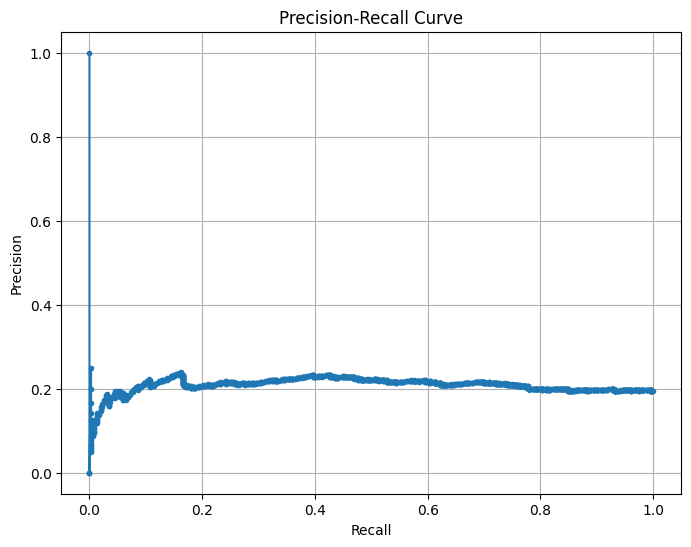

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx] if best_threshold_idx < len(thresholds) else 0.5

print(f"Best threshold: {best_threshold:.4f}")
print(f"F1-score at best threshold: {f1_scores[best_threshold_idx]:.4f}")
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

print(f"\nResults with optimal threshold ({best_threshold:.4f}):")
print(f"Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['No Attrition', 'Attrition']))
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

## Applying k-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')
cv_auc = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')

print("Cross-Validation Results:")
print(f"F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"AUC-ROC: {cv_auc.mean():.4f} (+/- {cv_auc.std() * 2:.4f})")
print(f"F1 scores per fold: {cv_scores}")
print(f"AUC scores per fold: {cv_auc}")

Cross-Validation Results:
F1-Score: 0.1499 (+/- 0.0347)
AUC-ROC: 0.4997 (+/- 0.0171)
F1 scores per fold: [0.14675052 0.18105263 0.15349887 0.13219616 0.13596491]
AUC scores per fold: [0.5023984  0.51148707 0.49660099 0.48553944 0.50265445]


In [ ]:
import joblib
joblib.dump(best_model, 'xg_boost_model.joblib')

['xg_boost_model.joblib']